### PFE Droin Charlotte & Lecoeur Bertrand

# Projet 2 : Pricing et calibration d'options sur VIX

L'objectif est d'étudier le pricing et la calibration d'options sur le VIX dans le cadre d'un modèle stochastique de courbe de variance forward.



## 1 Initialisation et fonctions mathématiques

## 1.1 Initialisation et fonctions de Pricing
Importation des modules nécessaires au projet et définition des fonctions analytiques de base. La convention de marché pour évaluer la volatilité implicite des options sur VIX consiste à utiliser le future VIX comme paramètre spot dans la formule de Black-Scholes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq, least_squares
from google.colab import files

# Importation des fichiers locaux
uploaded = files.upload()

# Définition des fonctions analytiques de pricing
def black_call(F, K, T, vol):
    # Retour de la valeur intrinsèque si la volatilité ou la maturité est nulle
    if vol <= 0 or T <= 0: return max(F - K, 0.0)
    srt = vol * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * vol * vol * T) / srt
    d2 = d1 - srt
    return F * norm.cdf(d1) - K * norm.cdf(d2)

def black_put(F, K, T, vol):
    # Retour de la valeur intrinsèque si la volatilité ou la maturité est nulle
    if vol <= 0 or T <= 0: return max(K - F, 0.0)
    srt = vol * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * vol * vol * T) / srt
    d2 = d1 - srt
    return K * norm.cdf(-d2) - F * norm.cdf(-d1)

# Inversion numérique pour l'extraction de la volatilité implicite
def implied_vol_black(price, F, K, T, is_call=True):
    intrinsic = max(F - K, 0.0) if is_call else max(K - F, 0.0)
    if price <= intrinsic + 1e-12:
        return np.nan
    try:
        if is_call:
            return brentq(lambda vol: black_call(F, K, T, vol) - price, 1e-6, 10.0)
        else:
            return brentq(lambda vol: black_put(F, K, T, vol) - price, 1e-6, 10.0)
    except:
        return np.nan


Saving vix_quotedata (2).csv to vix_quotedata (2).csv


## 1.2 Traitement des données du marché
Lecture des données et sélection de la maturité d'étude. On se restreint aux cotations qui ont un volume positif. Le prix de référence utilisé est $Mid=\frac{1}{2}(Bid+Ask)$. Le Future VIX implicite ($F_{0}$) est ensuite déduit de la relation de parité Call-Put.

In [ ]:
# Lecture du fichier de cotations
df = pd.read_csv("vix_quotedata (2).csv", skiprows=3)

# Filtrage sur la maturité cible
df = df[df["Expiration Date"] == "Wed Apr 29 2026"].copy()

# Conversion des colonnes de prix en format numérique
cols_to_numeric = ["Strike", "Bid", "Ask", "Bid.1", "Ask.1"]
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Exclusion des lignes sans cotation stricte
df = df[(df["Bid"] > 0) & (df["Ask"] > 0) & (df["Bid.1"] > 0) & (df["Ask.1"] > 0)].copy()

# Calcul des prix Mid pour les Calls et les Puts
df["Mid_Call"] = 0.5 * (df["Bid"] + df["Ask"])
df["Mid_Put"] = 0.5 * (df["Bid.1"] + df["Ask.1"])

# Calcul du Future VIX via la relation de parité Call-Put
df["Synthetic_Forward"] = df["Mid_Call"] - df["Mid_Put"] + df["Strike"]
F0_mkt = df["Synthetic_Forward"].median()
print(f"Future VIX implicite déduit du marché (F0) : {F0_mkt:.4f}\n")

Future VIX implicite déduit du marché (F0) : 20.8675



## 1.3 Extraction de la volatilité implicite et affichage du Smile
À partir des prix $Mid$ calculés et de la valeur du future, la volatilité implicite est extraite numériquement. Les données sont ensuite restreintes sur la zone de strikes pertinente pour visualiser la courbe du smile.

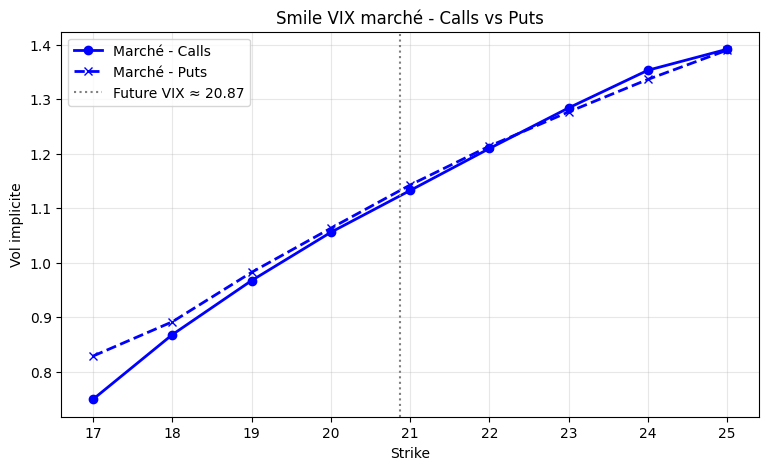

In [ ]:
# Initialisation de la maturité et des listes de résultats
T_mkt = 16 / 365
iv_recalc_calls = []
iv_recalc_puts = []

# Calcul itératif de la volatilité implicite pour chaque strike
for index, row in df.iterrows():
    K = row["Strike"]
    iv_recalc_calls.append(implied_vol_black(row["Mid_Call"], F0_mkt, K, T_mkt, is_call=True))
    iv_recalc_puts.append(implied_vol_black(row["Mid_Put"], F0_mkt, K, T_mkt, is_call=False))

# Intégration des résultats au DataFrame
df["IV_Recalc_Call"] = iv_recalc_calls
df["IV_Recalc_Put"] = iv_recalc_puts

# Suppression des valeurs indéfinies et restriction de la plage de strikes
df_clean = df.dropna(subset=["IV_Recalc_Call", "IV_Recalc_Put"]).copy()
df_clean = df_clean[(df_clean["Strike"] >= 15) & (df_clean["Strike"] <= 25)]

# Extraction des vecteurs finaux pour l'affichage et la suite de l'étude
strikes_mkt = df_clean["Strike"].values
iv_mkt_calls = df_clean["IV_Recalc_Call"].values
iv_mkt_puts = df_clean["IV_Recalc_Put"].values

# Construction du graphique du smile de volatilité
plt.figure(figsize=(9,5))
plt.plot(strikes_mkt, iv_mkt_calls, "o-", color="blue", lw=2, label="Marché - Calls")
plt.plot(strikes_mkt, iv_mkt_puts, "x--", color="blue", lw=2, label="Marché - Puts")
plt.axvline(F0_mkt, color="gray", ls=":", label=f"Future VIX ≈ {F0_mkt:.2f}")
plt.xlabel("Strike")
plt.ylabel("Vol implicite")
plt.title("Smile VIX marché - Calls vs Puts")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 2. Le Modèle de Bergomi (1 facteur)

Dans ce modèle, la fonction $\varphi$ est définie par une exponentielle décroissante :
$$\varphi(\tau) = \omega e^{-k\tau}$$
où $\omega$ représente la volatilité de variance et $1/k$ l'échelle de temps caractéristique.



## 2.1 Simulation Modèle de Bergomi à 1 Facteur
Ici, le modèle de Bergomi standard est implémenté. L'intégrale de la variance forward est approchée par une formule des rectangles. La fonction exponentielle du modèle permet d'utiliser la représentation markovienne avec le processus d'Ornstein-Uhlenbeck $X_{T}$ simulé par méthode de Monte-Carlo couplé à une technique de variables antithétiques pour réduire la variance.

In [ ]:
# Définition des paramètres du modèle
r = 0.0                # Taux d'intérêt fixé par hypothèse
delta = 1/12           # Environ 30 jours
T = T_mkt              # Maturité d'évaluation
sigma0 = 0.20          # Volatilité initiale
xi0 = sigma0**2        # Variance initiale
omega = 1.5            # Volatilité de la variance
k = 3.0                # Paramètre de retour à la moyenne

# Configuration de la simulation Monte-Carlo
n_mc = 50000
n_rect = 120
np.random.seed(42)

# Simulation de la variable de variance forward à maturité
# Processus d'Ornstein-Uhlenbeck pour X_T
var_XT = (1.0 - np.exp(-2.0 * k * T)) / (2.0 * k)
Z = np.random.randn(n_mc // 2)
Z_anti = np.concatenate((Z, -Z))
X_T = np.sqrt(var_XT) * Z_anti

# Discrétisation de l'intégrale par la méthode des rectangles
du = delta / n_rect
vix2 = np.zeros(n_mc)

for j in range(n_rect):
    u = T + (j + 0.5) * du
    a = np.exp(-k * (u - T))
    xi_T_u = xi0 * np.exp(omega * a * X_T - 0.5 * (omega**2) * (a**2) * var_XT)
    vix2 += xi_T_u * du

vix2 = vix2 / delta
VIX_T_sim = np.sqrt(vix2)

# Calcul de l'espérance pour obtenir le Future VIX simulé
F0_model = np.mean(VIX_T_sim)

## 2.2 Pricing et Extraction de la Volatilité Implicite
À partir des trajectoires simulées du VIX à maturité, les options Calls et Puts sont valorisées en calculant l'espérance de leurs payoffs. La volatilité implicite est ensuite extraite numériquement pour chaque instrument en utilisant le prix modélisé.

In [ ]:
# Évaluation Monte-Carlo des options
# Utilisation du vecteur de strikes défini précédemment
K_model = strikes_mkt / 100.0

call_prices = []
put_prices = []

for K in K_model:
    # Calcul des payoffs
    payoff_c = np.maximum(VIX_T_sim - K, 0.0)
    payoff_p = np.maximum(K - VIX_T_sim, 0.0)

    # Estimation de l'espérance des prix
    call_prices.append(np.mean(payoff_c))
    put_prices.append(np.mean(payoff_p))

# Inversion de la formule de Black pour la volatilité implicite
iv_model_calls = []
iv_model_puts = []

for i in range(len(K_model)):
    K = K_model[i]

    # Inversion pour les Calls
    vol_c = implied_vol_black(call_prices[i], F0_model, K, T, is_call=True)
    iv_model_calls.append(vol_c)

    # Inversion pour les Puts
    vol_p = implied_vol_black(put_prices[i], F0_model, K, T, is_call=False)
    iv_model_puts.append(vol_p)

# Conversion des listes en tableaux NumPy
iv_model_calls = np.array(iv_model_calls)
iv_model_puts = np.array(iv_model_puts)

## 2.3 Visualisation et Évaluation de l'Erreur MSE
Le smile de volatilité implicite produit par le modèle de Bergomi à un facteur est superposé aux données du marché. L'erreur quadratique moyenne (MSE) est calculée en se concentrant sur la zone Out-of-the-Money (OTM) pour une meilleure robustesse numérique (les *Puts* pour les *strikes* inférieurs au *forward*, et les *Calls* pour les *strikes* supérieurs). Le modèle à 1 facteur produit un smile plus plat que celui observé.

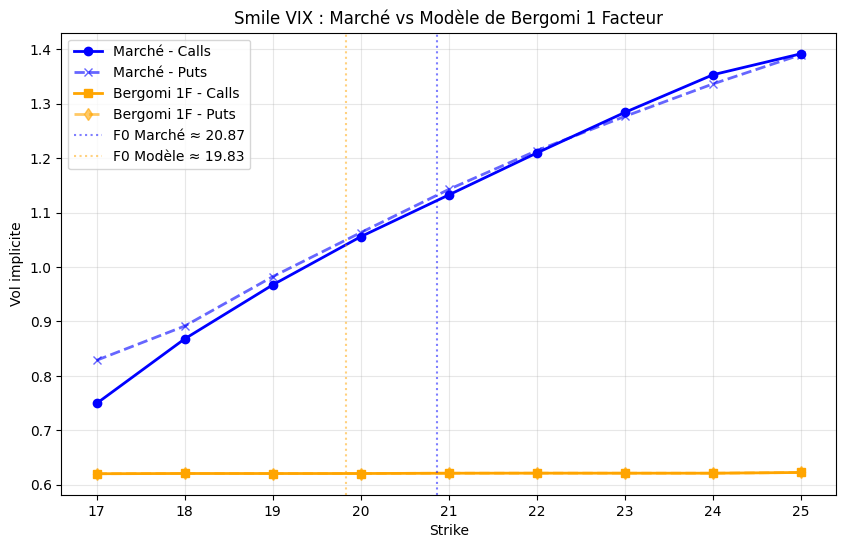


Performances du modèle 1 Facteur (non calibré) :
- Future VIX Modèle : 19.8305
- MSE : 0.289953


In [ ]:
# Configuration de la figure pour la comparaison graphique
plt.figure(figsize=(10,6))

# Tracé des données de marché
plt.plot(strikes_mkt, iv_mkt_calls, "o-", lw=2, color="blue", label="Marché - Calls")
plt.plot(strikes_mkt, iv_mkt_puts, "x--", lw=2, color="blue", alpha=0.6, label="Marché - Puts")

# Tracé des résultats du modèle à 1 facteur
plt.plot(strikes_mkt, iv_model_calls, "s-", lw=2, color="orange", label="Bergomi 1F - Calls")
plt.plot(strikes_mkt, iv_model_puts, "d--", lw=2, color="orange", alpha=0.6, label="Bergomi 1F - Puts")

# Indication visuelle des valeurs Forward
plt.axvline(F0_mkt, color="blue", ls=":", alpha=0.5, label=f"F0 Marché ≈ {F0_mkt:.2f}")
plt.axvline(F0_model * 100, color="orange", ls=":", alpha=0.5, label=f"F0 Modèle ≈ {F0_model * 100:.2f}")

plt.xlabel("Strike")
plt.ylabel("Vol implicite")
plt.title("Smile VIX : Marché vs Modèle de Bergomi 1 Facteur")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Évaluation de l'erreur quadratique moyenne (MSE)
erreur_globale_1f = 0.0
points_valides_1f = 0

for i in range(len(strikes_mkt)):
    K_val = strikes_mkt[i] / 100.0

    if K_val < F0_model:
        # Sélection des Puts Out-of-the-Money
        if np.isfinite(iv_model_puts[i]) and np.isfinite(iv_mkt_puts[i]):
            erreur_globale_1f += (iv_mkt_puts[i] - iv_model_puts[i])**2
            points_valides_1f += 1
    else:
        # Sélection des Calls Out-of-the-Money
        if np.isfinite(iv_model_calls[i]) and np.isfinite(iv_mkt_calls[i]):
            erreur_globale_1f += (iv_mkt_calls[i] - iv_model_calls[i])**2
            points_valides_1f += 1

mse_1f = erreur_globale_1f / max(points_valides_1f, 1)

print(f"\nPerformances du modèle 1 Facteur (non calibré) :")
print(f"- Future VIX Modèle : {F0_model * 100:.4f}")
print(f"- MSE : {mse_1f:.6f}")

## 3. Modèle Mélange d'Exponentielles



## 3.1 Modèle Mélange d'Exponentielles (Simulation)
Le modèle de Bergomi classique produit souvent un *smile* trop plat. Pour générer un *skew* positif prononcé tel qu'observé sur le marché du VIX, un mélange d'exponentielles est implémenté. L'équation de la variance forward intègre un nouveau paramètre de pondération $\gamma$ et deux niveaux de volatilité de la variance ($\omega_{1}$ et $\omega_{2}$).

In [ ]:
# Configuration des paramètres de marché initiaux
r = 0.0
delta = 1/12          # 30 jours (période VIX)
T = T_mkt             # Maturité d'évaluation
sigma0 = F0_mkt / 100.0
xi0 = sigma0**2       # Variance initiale

# Paramètres spécifiques au mélange d'exponentielles
omega1 = 5.0
omega2 = 0.5
k = 3.0
gamma = 0.5

# Configuration Monte-Carlo
n_mc = 50000
n_rect = 120
np.random.seed(123)

# Calcul du facteur markovien X_T
var_XT = (1.0 - np.exp(-2.0 * k * T)) / (2.0 * k)

# Génération aléatoire avec variables antithétiques
Z = np.random.randn(n_mc // 2)
Z_anti = np.concatenate((Z, -Z))
X_T = np.sqrt(var_XT) * Z_anti

# Simulation de l'intégrale de la variance
du = delta / n_rect
vix2_mix = np.zeros(n_mc)

for j in range(n_rect):
    u = T + (j + 0.5) * du
    a = np.exp(-k * (u - T))

    # Premier terme du mélange : dépend de X_T (intégré jusqu'à T)
    G1 = np.exp(omega1 * a * X_T - 0.5 * (omega1 * a)**2 * var_XT)

    # Second terme du mélange : dépend de X_T et d'un incrément indépendant
    #var_eps = (1.0 - a**2) / (2.0 * k)                    # Variance de l'incrément
    #eps_u   = np.sqrt(var_eps) * np.random.randn(n_mc)    # Bruit indépendant
    #G2 = np.exp(
    #    omega2 * a * X_T + omega2 * eps_u
    #    - 0.5 * omega2**2 * (a**2 * var_XT + var_eps)
    #)
    G2 = np.exp(
        omega2 * a * X_T
        - 0.5 * (omega2 * a)**2 * var_XT
    )

    # Combinaison linéaire pondérée par gamma
    xi_T_u_mix = xi0 * ((1.0 - gamma) * G1 + gamma * G2)
    vix2_mix += xi_T_u_mix * du

vix2_mix = vix2_mix / delta

# Sécurité numérique : évite les valeurs négatives sous la racine
VIX_T_mix = np.sqrt(np.maximum(vix2_mix, 0.0))

# Extraction de l'espérance pour le Future VIX modélisé
F0_mix = np.mean(VIX_T_mix)

## 3.2 Pricing et Extraction
Sur la base des trajectoires générées par le nouveau modèle de mélange d'exponentielles, les options sont valorisées. Leurs volatilités implicites respectives sont ensuite extraites numériquement pour reconstituer le *smile* simulé.

In [ ]:
K_model = strikes_mkt / 100.0

call_prices_mix = []
put_prices_mix = []

# Calcul de l'espérance des payoffs sur les trajectoires simulées
for K in K_model:
    call_prices_mix.append(np.mean(np.maximum(VIX_T_mix - K, 0.0)))
    put_prices_mix.append(np.mean(np.maximum(K - VIX_T_mix, 0.0)))

iv_model_mix_calls = []
iv_model_mix_puts = []

for i in range(len(K_model)):
    K = K_model[i]

    # Inversion de la formule de Black pour les Calls
    vol_c = implied_vol_black(call_prices_mix[i], F0_mix, K, T, is_call=True)
    iv_model_mix_calls.append(vol_c)

    # Inversion de la formule de Black pour les Puts
    vol_p = implied_vol_black(put_prices_mix[i], F0_mix, K, T, is_call=False)
    iv_model_mix_puts.append(vol_p)

iv_model_mix_calls = np.array(iv_model_mix_calls)
iv_model_mix_puts = np.array(iv_model_mix_puts)

## 3.3 Visualisation et Évaluation
Le nouveau *smile* généré par le modèle mélange est comparé aux cibles du marché. Le *skew* est plus accentué et l'erreur quadratique moyenne globale reflète un meilleur ajustement.

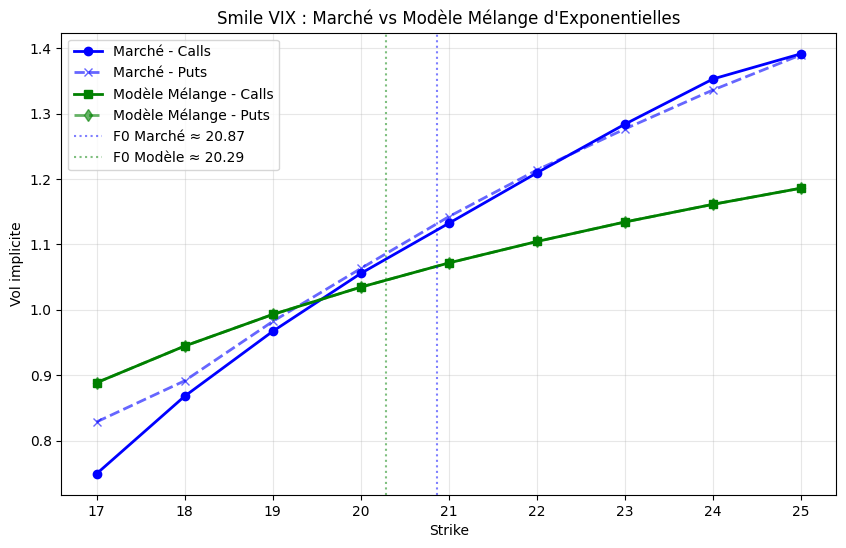


Performances du modèle Mélange (non calibré) :
- Future VIX Modèle : 20.2859
- MSE : 0.013715


In [ ]:
# Initialisation du graphique
plt.figure(figsize=(10,6))

# Tracé des volatilités implicites du marché
plt.plot(strikes_mkt, iv_mkt_calls, "o-", lw=2, color="blue", label="Marché - Calls")
plt.plot(strikes_mkt, iv_mkt_puts, "x--", lw=2, color="blue", alpha=0.6, label="Marché - Puts")

# Tracé des volatilités implicites du modèle mélange
plt.plot(strikes_mkt, iv_model_mix_calls, "s-", lw=2, color="green", label="Modèle Mélange - Calls")
plt.plot(strikes_mkt, iv_model_mix_puts, "d--", lw=2, color="green", alpha=0.6, label="Modèle Mélange - Puts")

# Affichage des points de référence (Futures)
plt.axvline(F0_mkt, color="blue", ls=":", alpha=0.5, label=f"F0 Marché ≈ {F0_mkt:.2f}")
plt.axvline(F0_mix * 100, color="green", ls=":", alpha=0.5, label=f"F0 Modèle ≈ {F0_mix * 100:.2f}")

plt.xlabel("Strike")
plt.ylabel("Vol implicite")
plt.title("Smile VIX : Marché vs Modèle Mélange d'Exponentielles")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Calcul de l'erreur MSE sur la zone Out-of-the-Money
erreur_globale_mix = 0.0
points_valides_mix = 0

for i in range(len(strikes_mkt)):
    K_val = strikes_mkt[i] / 100.0

    if K_val < F0_mix:
        # Puts (strikes inférieurs au Forward)
        if np.isfinite(iv_model_mix_puts[i]) and np.isfinite(iv_mkt_puts[i]):
            erreur_globale_mix += (iv_mkt_puts[i] - iv_model_mix_puts[i])**2
            points_valides_mix += 1
    else:
        # Calls (strikes supérieurs au Forward)
        if np.isfinite(iv_model_mix_calls[i]) and np.isfinite(iv_mkt_calls[i]):
            erreur_globale_mix += (iv_mkt_calls[i] - iv_model_mix_calls[i])**2
            points_valides_mix += 1

mse_mix = erreur_globale_mix / max(points_valides_mix, 1)

print(f"\nPerformances du modèle Mélange (non calibré) :")
print(f"- Future VIX Modèle : {F0_mix * 100:.4f}")
print(f"- MSE : {mse_mix:.6f}")

## 4. Comparaison des modèles

Nous mettons en évidence la limite du modèle de Bergomi à un facteur en comparant visuellement les données du marché avec ce modèle et une première évaluation du modèle de mélange.

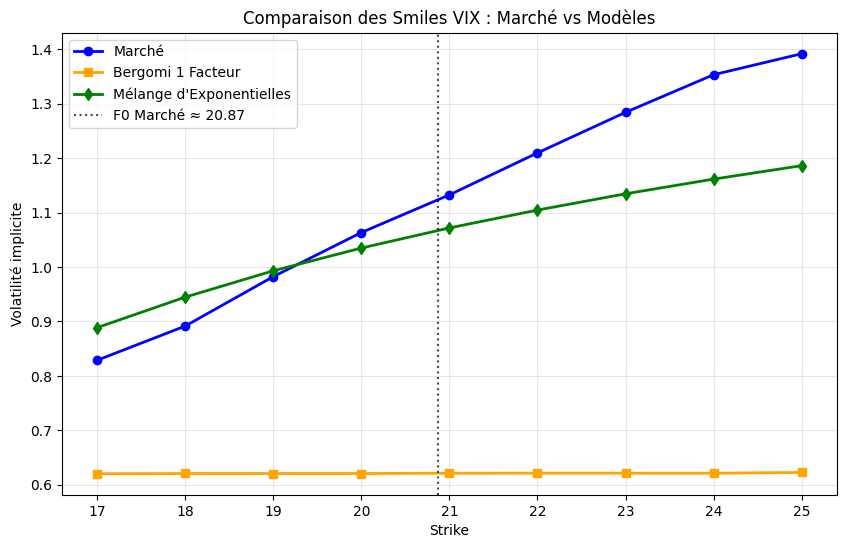

 TABLEAU COMPARATIF DES VOLATILITÉS IMPLICITES 
 Strike   Marché 1 Facteur  Mélange
   17.0  82.88 %   62.04 %  88.87 %
   18.0  89.16 %   62.08 %  94.47 %
   19.0  98.24 %   62.08 %   99.3 %
   20.0 106.33 %   62.08 % 103.48 %
   21.0 113.25 %   62.13 % 107.18 %
   22.0 120.95 %   62.15 % 110.46 %
   23.0  128.4 %   62.14 % 113.44 %
   24.0 135.31 %   62.14 % 116.14 %
   25.0 139.16 %   62.27 % 118.61 %

PERFORMANCES DES MODÈLES AVANT CALIBRATION
MSE - Bergomi 1 facteur : 0.289953
MSE - Modèle mélange    : 0.013715


In [ ]:
# Construction des courbes de volatilité OTM (Out-Of-The-Money)
# Règle de sélection : Puts pour K < F0, Calls pour K >= F0
iv_mkt_otm = np.where(strikes_mkt < F0_mkt, iv_mkt_puts, iv_mkt_calls)

# Ajustement d'échelle : conversion des Futures modèles en points VIX (×100) pour la condition logique
iv_1f_otm  = np.where(strikes_mkt < F0_model * 100, iv_model_puts,     iv_model_calls)
iv_mix_otm = np.where(strikes_mkt < F0_mix   * 100, iv_model_mix_puts, iv_model_mix_calls)

# Visualisation Graphique
plt.figure(figsize=(10, 6))

# Tracé des courbes OTM consolidées
plt.plot(strikes_mkt, iv_mkt_otm, "o-", color="blue", lw=2, label="Marché")
plt.plot(strikes_mkt, iv_1f_otm, "s-", color="orange", lw=2, label="Bergomi 1 Facteur")
plt.plot(strikes_mkt, iv_mix_otm, "d-", color="green", lw=2, label="Mélange d'Exponentielles")

# Repère visuel du Future de marché
plt.axvline(F0_mkt, color="black", ls=":", alpha=0.7, label=f"F0 Marché ≈ {F0_mkt:.2f}")

plt.xlabel("Strike")
plt.ylabel("Volatilité implicite")
plt.title("Comparaison des Smiles VIX : Marché vs Modèles")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Constitution du tableau comparatif des volatilités
comparaison_otm = pd.DataFrame({
    "Strike": strikes_mkt,
    "Marché": iv_mkt_otm,
    "1 Facteur": iv_1f_otm,
    "Mélange": iv_mix_otm
})

# Formatage de l'affichage en pourcentages pour la présentation
comparaison_affichee = comparaison_otm.copy()
colonnes_vol = comparaison_affichee.columns[1:]
for col in colonnes_vol:
    comparaison_affichee[col] = (comparaison_affichee[col] * 100).round(2).astype(str) + " %"

# Affichage du tableau de synthèse
print(" TABLEAU COMPARATIF DES VOLATILITÉS IMPLICITES ")
print(comparaison_affichee.to_string(index=False))
print("=====================================================\n")

# Bilan chiffré des erreurs quadratiques moyennes (MSE)
print("PERFORMANCES DES MODÈLES AVANT CALIBRATION")
print(f"MSE - Bergomi 1 facteur : {mse_1f:.6f}")
print(f"MSE - Modèle mélange    : {mse_mix:.6f}")


## 5. Calibration du Modèle Mélange d'Exponentielles

L'objectif ici est de tenter une calibration à la volatilité implicite marché du VIX en faisant varier les paramètres $\omega_1$, $\omega_2$, $k>0$ et $\gamma\in(0,1)$. Pour cela, nous allons utiliser l'algorithme d'optimisation de Levenberg-Marquardt.

## 5.1 Préparation à la Calibration Paramètres et Fonctions Sécurisées
Importation des modules d'optimisation et redéfinition des fonctions de *pricing* avec des limites numériques pour assurer la stabilité de la calibration. Une fonction sigmoïde est également définie pour contraindre ultérieurement le paramètre $\gamma$ dans l'intervalle $(0, 1)$.

In [ ]:
# Paramètres et hypothèses de marché
r = 0.0
delta = 1/12             # Période d'intégration du VIX (30 jours)
T = 16/365               # Maturité
sigma0 = 0.2018          # Volatilité initiale observée
xi0 = sigma0**2          # Variance forward initiale supposée constante

# Fonctions analytiques de pricing sécurisées
def black_call(F, K, T, vol):
    if vol <= 0 or T <= 0: return max(F - K, 0.0)
    srt = vol * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * vol * vol * T) / srt
    d2 = d1 - srt
    return F * norm.cdf(d1) - K * norm.cdf(d2)

def black_put(F, K, T, vol):
    if vol <= 0 or T <= 0: return max(K - F, 0.0)
    srt = vol * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * vol * vol * T) / srt
    d2 = d1 - srt
    return K * norm.cdf(-d2) - F * norm.cdf(-d1)

def implied_vol_black(price, F, K, T, is_call=True):
    intrinsic = max(F - K, 0.0) if is_call else max(K - F, 0.0)
    if price <= intrinsic + 1e-12:
        return np.nan
    upper = 10.0
    try:
        if is_call:
            return brentq(lambda vol: black_call(F, K, T, vol) - price, 1e-6, upper, maxiter=200)
        else:
            return brentq(lambda vol: black_put(F, K, T, vol) - price, 1e-6, upper, maxiter=200)
    except Exception:
        return np.nan

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

## 5.2 Modèle de Bergomi (Mélange d'Exponentielles)
Le modèle est encapsulé dans une fonction paramétrable afin d'être appelé itérativement par l'algorithme d'optimisation. La courbe de variance initiale $\xi_{0}$ est ajustée dynamiquement pour correspondre exactement à la valeur du Future VIX observée sur le marché ($F_{0}$ cible).

In [ ]:
# Modèle de Bergomi avec mélange d'exponentielles, encapsulé pour l'optimisation
def smile_model_mix(strikes_pts, F0_cible, omega1, omega2, k, gamma, n_mc=15000, n_rect=80, seed=12345):
    rng = np.random.default_rng(seed)

    var_XT = (1.0 - np.exp(-2.0 * k * T)) / (2.0 * k)
    Z = rng.standard_normal(n_mc // 2)
    Z_anti = np.concatenate((Z, -Z))
    X_T = np.sqrt(var_XT) * Z_anti

    du = delta / n_rect
    vix2_stoch = np.zeros(n_mc)

    for j in range(n_rect):
        u = T + (j + 0.5) * du
        a = np.exp(-k * (u - T))

        # Évaluation du premier terme du mélange (dépendant de X_T)
        G1 = np.exp(omega1 * a * X_T - 0.5 * (omega1**2) * (a**2) * var_XT)

        # Évaluation du second terme du mélange (dépendant de X_T et d'un incrément indépendant)
        var_eps = (1.0 - a**2) / (2.0 * k)
        eps_u   = np.sqrt(var_eps) * rng.standard_normal(n_mc)
        #G2 = np.exp(
        #    omega2 * a * X_T + omega2 * eps_u
        #    - 0.5 * omega2**2 * (a**2 * var_XT + var_eps)
        #)
        G2 = np.exp(
        omega2 * a * X_T
        - 0.5 * (omega2 * a)**2 * var_XT)

        # Intégration de la dynamique stochastique pure
        stoch_part = ((1.0 - gamma) * G1 + gamma * G2)
        vix2_stoch += (stoch_part * du)

    # Ajustement dynamique du niveau de variance initiale
    # Calcul du VIX non normalisé
    VIX_T_unscaled = np.sqrt(np.maximum(vix2_stoch / delta, 0.0)) * 100.0

    # Calcul du ratio d'ajustement pour atteindre la cible F0
    ratio_ajustement = F0_cible / np.mean(VIX_T_unscaled)

    # Application du ratio d'ajustement aux trajectoires
    VIX_T = VIX_T_unscaled * ratio_ajustement

    F0_model = np.mean(VIX_T)

    iv_model = []
    for K in strikes_pts:
        if K < F0_model:
            p_put = np.mean(np.maximum(K - VIX_T, 0.0))
            vol = implied_vol_black(p_put, F0_model, K, T, is_call=False)
        else:
            p_call = np.mean(np.maximum(VIX_T - K, 0.0))
            vol = implied_vol_black(p_call, F0_model, K, T, is_call=True)

        iv_model.append(vol)

    return np.array(iv_model), F0_model

## 5.3 Définition de l'Objectif et Lancement de la Calibration
L'algorithme de Levenberg-Marquardt est utilisé pour minimiser l'écart  entre la volatilité implicite simulée et celle du marché. Afin de respecter les contraintes de positivité des paramètres et d'appartenance de $\gamma$ à $(0,1)$, des transformations mathématiques (logarithme et logit) sont appliquées aux variables d'optimisation.

In [ ]:
# Fonction des paramètres optimisés
def unpack_params(theta):
    a, b, c, d = theta
    omega1 = np.exp(a)
    omega2 = np.exp(b)
    k = np.exp(c)
    gamma = sigmoid(d)
    return omega1, omega2, k, gamma

# Fonction objectif évaluant l'écart avec les données du marché
def residuals(theta):
    omega1, omega2, k, gamma = unpack_params(theta)

    # Évaluation du modèle avec un nombre réduit de trajectoires pour l'optimisation
    iv_model, _ = smile_model_mix(
        strikes_pts=strikes_mkt,
        F0_cible=F0_mkt,
        omega1=omega1,
        omega2=omega2,
        k=k,
        gamma=gamma,
        n_mc=15000,
        n_rect=60,
        seed=2026
    )

    # Traitement des valeurs non définies
    iv_model = np.where(np.isnan(iv_model), 3.0, iv_model)

    # Retour des résidus calculés sur la zone OTM
    return iv_model - iv_mkt_otm


# Initialisation des paramètres de départ
omega1_0 = 2.0
omega2_0 = 0.2
k_0 = 3.0
gamma_0 = 0.5

# Transformations mathématiques pour l'optimisation non contrainte
log_omega1 = np.log(omega1_0)
log_omega2 = np.log(omega2_0)
log_k = np.log(k_0)
logit_gamma = np.log(gamma_0 / (1.0 - gamma_0))

# Constitution du vecteur d'état initial
theta0 = np.array([log_omega1, log_omega2, log_k, logit_gamma])

# Lancement de l'algorithme des moindres carrés non linéaires
res = least_squares(
    residuals,
    theta0,
    method="lm",
    max_nfev=400,
    xtol=1e-6,
    ftol=1e-6,
    gtol=1e-6
)

# Extraction des paramètres calibrés
theta_optimal = res.x
omega1_cal, omega2_cal, k_cal, gamma_cal = unpack_params(theta_optimal)
ratio_omega = omega1_cal / omega2_cal

print("RÉSULTATS DE CALIBRATION")
print(f"omega1 optimisé = {omega1_cal:.6f}")
print(f"omega2 optimisé = {omega2_cal:.6f}")
print(f"k optimisé      = {k_cal:.6f}")
print(f"gamma optimisé  = {gamma_cal:.6f}")
print(f"Ratio w1/w2     = {ratio_omega:.3f}")

RÉSULTATS DE CALIBRATION
omega1 optimisé = 8.810302
omega2 optimisé = 0.979807
k optimisé      = 0.000004
gamma optimisé  = 0.724550
Ratio w1/w2     = 8.992


## 5.4 Validation et Affichage
Le modèle est relancé une dernière fois avec les paramètres optimisés en utilisant un nombre de chemins Monte-Carlo élevé afin de garantir la précision du résultat. L'erreur quadratique moyenne finale est mesurée et le *smile* calibré est superposé aux données de marché. Comme mentionné dans le sujet $\gamma$ devrait être proche de $0.5$ et le ratio $\frac{\omega_{1}}{\omega_{2}}$ proche de $10$.

MSE Finale (après calibration) : 0.000131



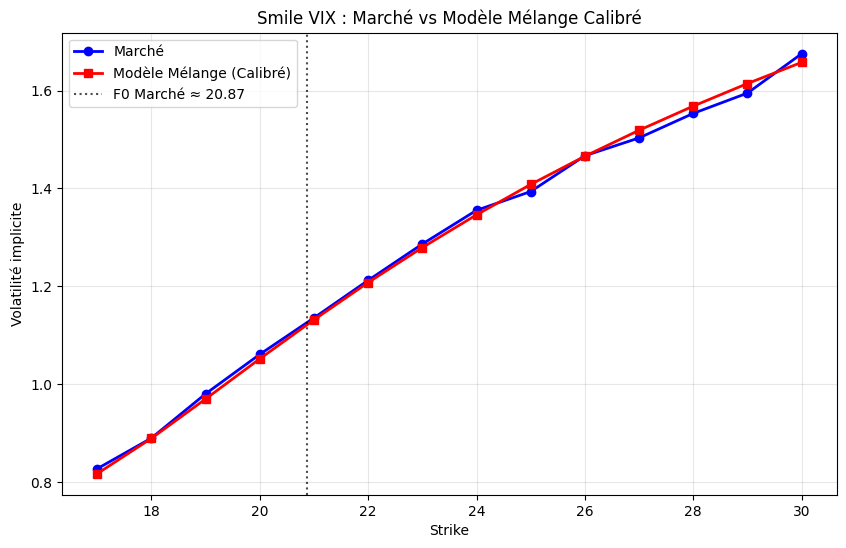

In [ ]:
# Évaluation finale du modèle avec les paramètres optimaux
iv_calibrated, F0_calibrated = smile_model_mix(
    strikes_pts=strikes_mkt,
    F0_cible=F0_mkt,
    omega1=omega1_cal,
    omega2=omega2_cal,
    k=k_cal,
    gamma=gamma_cal,
    n_mc=50000,
    n_rect=120,
    seed=9999
)

# Évaluation de la précision finale via la MSE
iv_calibrated = np.where(np.isnan(iv_calibrated), 3.0, iv_calibrated)
mse_finale = np.mean((iv_calibrated - iv_mkt_otm)**2)

print(f"MSE Finale (après calibration) : {mse_finale:.6f}\n")

# Création du graphique de comparaison final
plt.figure(figsize=(10, 6))

# Tracé des données cibles du marché
plt.plot(strikes_mkt, iv_mkt_otm, "o-", color="blue", lw=2, label="Marché")

# Tracé de la courbe générée par le modèle calibré
plt.plot(strikes_mkt, iv_calibrated, "s-", color="red", lw=2, label="Modèle Mélange (Calibré)")

# Affichage du marqueur pour le Future VIX
plt.axvline(F0_mkt, color="black", ls=":", alpha=0.7, label=f"F0 Marché ≈ {F0_mkt:.2f}")

plt.xlabel("Strike")
plt.ylabel("Volatilité implicite")
plt.title("Smile VIX : Marché vs Modèle Mélange Calibré")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Calibration Multi-Maturités

## 6.1 Paramètres Globaux et Fonctions de Base
Cette section étend le modèle de Bergomi à une structure par terme. Les paramètres globaux du marché sont définis et les fonctions de *pricing* analytiques sont initialisées. Le paramètre de retour à la moyenne $k$ est maintenu constant.

In [ ]:
# Définition des hypothèses de marché et des paramètres globaux
quote_date = pd.Timestamp("2026-04-13")
sigma0 = 0.2018              # Volatilité initiale
xi0 = sigma0**2              # Variance forward initiale
delta = 1.0 / 12.0           # Incrément temporel (30 jours)
r = 0.0                      # Taux d'intérêt sans risque

# Récupération du paramètre k calibré précédemment ou assignation de la valeur par défaut
k_global = k_cal if 'k_cal' in locals() else 3.0

# Fonctions analytiques de pricing et d'inversion sécurisées
def black_call(F, K, T, vol):
    if vol <= 0 or T <= 0: return max(F - K, 0.0)
    srt = vol * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * vol * vol * T) / srt
    d2 = d1 - srt
    return F * norm.cdf(d1) - K * norm.cdf(d2)

def black_put(F, K, T, vol):
    if vol <= 0 or T <= 0: return max(K - F, 0.0)
    srt = vol * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * vol * vol * T) / srt
    d2 = d1 - srt
    return K * norm.cdf(-d2) - F * norm.cdf(-d1)

def implied_vol_black(price, F, K, T, is_call=True):
    intrinsic = max(F - K, 0.0) if is_call else max(K - F, 0.0)
    if price <= intrinsic + 1e-12:
        return np.nan
    try:
        if is_call:
            return brentq(lambda vol: black_call(F, K, T, vol) - price, 1e-6, 10.0, maxiter=200)
        else:
            return brentq(lambda vol: black_put(F, K, T, vol) - price, 1e-6, 10.0, maxiter=200)
    except:
        return np.nan

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

## 6.2 Moteur de Simulation Multi-Maturités
Le modèle de mélange d'exponentielles est adapté pour accepter la maturité $T$ comme variable d'entrée dynamique. La fonction simule les trajectoires du VIX pour une maturité donnée ajuste le niveau de variance initiale pour respecter la cible du *Future* puis extrait les volatilités implicites Out-Of-The-Money (OTM).

In [ ]:
# Fonction de simulation du modèle de Bergomi avec mélange paramétrée par la maturité
def smile_model_mix_multi(strikes_pts, F0_cible, T_val, omega1, omega2, k_val, gamma_val, n_mc=30000, n_rect=80, seed=12345):
    rng = np.random.default_rng(seed)

    var_XT = (1.0 - np.exp(-2.0 * k_val * T_val)) / (2.0 * k_val)

    Z = rng.standard_normal(n_mc // 2)
    Z_anti = np.concatenate((Z, -Z))
    X_T = np.sqrt(var_XT) * Z_anti

    du = delta / n_rect
    vix2_stoch = np.zeros(n_mc)

    for j in range(n_rect):
        u = T_val + (j + 0.5) * du
        a = np.exp(-k_val * (u - T_val))

        # Évaluation du premier terme du mélange
        G1 = np.exp(omega1 * a * X_T - 0.5 * (omega1**2) * (a**2) * var_XT)

        # Évaluation du second terme du mélange
        var_eps = (1.0 - a**2) / (2.0 * k_val)
        eps_u   = np.sqrt(var_eps) * rng.standard_normal(n_mc)
        #G2 = np.exp(
         #   omega2 * a * X_T + omega2 * eps_u
         #   - 0.5 * omega2**2 * (a**2 * var_XT + var_eps)
        #)
        G2 = np.exp(
        omega2 * a * X_T
        - 0.5 * (omega2 * a)**2 * var_XT)

        stoch_part = ((1.0 - gamma_val) * G1 + gamma_val * G2)
        vix2_stoch += (stoch_part * du)

    # Ajustement dynamique du niveau de la courbe pour atteindre la cible F0
    VIX_T_unscaled = np.sqrt(np.maximum(vix2_stoch / delta, 0.0)) * 100.0
    ratio_ajustement = F0_cible / np.mean(VIX_T_unscaled)
    VIX_T = VIX_T_unscaled * ratio_ajustement

    F0_model = np.mean(VIX_T)

    iv_model = []
    for K in strikes_pts:
        if K < F0_model:
            p_put = np.mean(np.maximum(K - VIX_T, 0.0))
            vol = implied_vol_black(p_put, F0_model, K, T_val, is_call=False)
        else:
            p_call = np.mean(np.maximum(VIX_T - K, 0.0))
            vol = implied_vol_black(p_call, F0_model, K, T_val, is_call=True)
        iv_model.append(vol)

    return np.array(iv_model), F0_model

## 6.3 Traitement des Données du Marché (Structure par Terme)
L'ensemble du fichier de cotations est parcouru afin d'extraire les *smiles* de volatilité implicite OTM pour toutes les maturités liquides disponibles. Les données aberrantes ou illiquides sont filtrées.

In [ ]:
# Chargement des données globales
df_all = pd.read_csv("vix_quotedata (2).csv", skiprows=3)

# Extraction des maturités uniques
toutes_maturites = df_all["Expiration Date"].unique()
expiries_valides = []
data_par_maturite = {}

for exp in toutes_maturites:
    df_mat = df_all[df_all["Expiration Date"] == exp].copy()

    cols = ["Strike", "Bid", "Ask", "Bid.1", "Ask.1"]
    for col in cols:
        df_mat[col] = pd.to_numeric(df_mat[col], errors="coerce")

    # Application du filtre de liquidité
    df_mat = df_mat[(df_mat["Bid"] > 0) & (df_mat["Ask"] > 0) & (df_mat["Bid.1"] > 0) & (df_mat["Ask.1"] > 0)].copy()

    # Restriction de la zone de strikes pour l'analyse
    df_mat = df_mat[(df_mat["Strike"] >= 15) & (df_mat["Strike"] <= 30)].copy()

    if len(df_mat) >= 5:
        # Calcul des prix de référence et du Forward implicite
        df_mat["Mid_Call"] = 0.5 * (df_mat["Bid"] + df_mat["Ask"])
        df_mat["Mid_Put"] = 0.5 * (df_mat["Bid.1"] + df_mat["Ask.1"])
        df_mat["Synthetic_Forward"] = df_mat["Mid_Call"] - df_mat["Mid_Put"] + df_mat["Strike"]
        F0_mkt_exp = df_mat["Synthetic_Forward"].median()

        # Conversion de la maturité en fraction d'année
        jours = (pd.to_datetime(exp) - quote_date).days
        T_exp = max(jours, 1) / 365.0

        # Extraction des volatilités implicites
        iv_calls, iv_puts = [], []
        for _, row in df_mat.iterrows():
            K = row["Strike"]
            iv_calls.append(implied_vol_black(row["Mid_Call"], F0_mkt_exp, K, T_exp, is_call=True))
            iv_puts.append(implied_vol_black(row["Mid_Put"], F0_mkt_exp, K, T_exp, is_call=False))

        df_mat["IV_Recalc_Call"] = iv_calls
        df_mat["IV_Recalc_Put"] = iv_puts
        df_mat = df_mat.dropna(subset=["IV_Recalc_Call", "IV_Recalc_Put"]).sort_values("Strike")

        if len(df_mat) >= 5:
            expiries_valides.append(exp)
            # Construction de la courbe OTM
            strikes = df_mat["Strike"].values
            iv_mkt_otm = np.where(strikes < F0_mkt_exp, df_mat["IV_Recalc_Put"].values, df_mat["IV_Recalc_Call"].values)

            data_par_maturite[exp] = {
                "T": T_exp,
                "F0_mkt": F0_mkt_exp,
                "strikes": strikes,
                "iv_mkt_otm": iv_mkt_otm
            }
            print(f"{exp} retenue : {len(strikes)} strikes valides (F0 Marché = {F0_mkt_exp:.2f})")

Wed Apr 15 2026 retenue : 20 strikes valides (F0 Marché = 20.46)
Wed Apr 22 2026 retenue : 15 strikes valides (F0 Marché = 21.06)
Wed Apr 29 2026 retenue : 14 strikes valides (F0 Marché = 20.86)


## 6.4 Calibration Séquentielle par Maturité
Une boucle itère sur l'ensemble des maturités valides. Pour chaque coupe temporelle l'algorithme des moindres carrés non linéaires optimise les paramètres $\omega_{1}$, $\omega_{2}$ et $\gamma$ afin de minimiser l'erreur avec le marché tout en conservant le $k$ constant.

In [ ]:
results = []
fits = {}

# Itération sur chaque maturité pour la calibration locale
for exp in expiries_valides:
    mkt_info = data_par_maturite[exp]
    T_exp = mkt_info["T"]
    F0_mkt_exp = mkt_info["F0_mkt"]
    strikes_mkt = mkt_info["strikes"]
    iv_mkt_otm = mkt_info["iv_mkt_otm"]

    # Définition de la fonction de coût pour l'optimiseur
    def residuals(theta):
        omega1 = np.exp(theta[0])
        omega2 = np.exp(theta[1])
        gamma = sigmoid(theta[2])

        iv_model, _ = smile_model_mix_multi(
            strikes_pts=strikes_mkt,
            F0_cible=F0_mkt_exp,
            T_val=T_exp,
            omega1=omega1,
            omega2=omega2,
            k_val=k_global,
            gamma_val=gamma,
            n_mc=15000,
            n_rect=60,
            seed=2026
        )

        iv_model = np.where(np.isnan(iv_model), 3.0, iv_model)
        return iv_model - iv_mkt_otm

    # Initialisation des paramètres de départ avec transformations mathématiques
    omega1_0, omega2_0, gamma_0 = 4.0, 0.3, 0.5
    theta0 = [np.log(omega1_0), np.log(omega2_0), np.log(gamma_0 / (1.0 - gamma_0))]

    # Lancement de l'algorithme d'optimisation
    res = least_squares(residuals, x0=theta0, method="lm", xtol=1e-5, ftol=1e-5, max_nfev=100)

    # Rétro-transformation des paramètres optimaux
    omega1_opt = np.exp(res.x[0])
    omega2_opt = np.exp(res.x[1])
    gamma_opt = sigmoid(res.x[2])

    # Évaluation de haute précision avec les paramètres calibrés
    iv_fit, F0_fit = smile_model_mix_multi(
        strikes_pts=strikes_mkt,
        F0_cible=F0_mkt_exp,
        T_val=T_exp,
        omega1=omega1_opt,
        omega2=omega2_opt,
        k_val=k_global,
        gamma_val=gamma_opt,
        n_mc=50000,
        n_rect=120,
        seed=9999
    )

    mse = np.mean((iv_fit - iv_mkt_otm)**2)

    # Enregistrement des résultats
    results.append({
        "Maturité": exp,
        "T (années)": np.round(T_exp, 4),
        "omega1": omega1_opt,
        "omega2": omega2_opt,
        "k (fixé)": k_global,
        "gamma": gamma_opt,
        "Ratio w1/w2": omega1_opt / omega2_opt,
        "F0 Modèle": F0_fit,
        "F0 Marché": F0_mkt_exp,
        "MSE": mse
    })

    fits[exp] = {
        "strikes": strikes_mkt,
        "iv_mkt": iv_mkt_otm,
        "iv_model": iv_fit
    }

## 6.5 Synthèse et Visualisation de la Surface de Volatilité Calibrée
Affichage d'un tableau récapitulatif des paramètres calibrés pour chaque maturité. Une grille graphique est ensuite générée pour comparer visuellement la dynamique des smiles générés par le modèle face aux cotations réelles sur l'ensemble de la structure par terme.

TABLEAU SYNTHÉTIQUE DE LA CALIBRATION
       Maturité  T (années)    omega1   omega2  k (fixé)    gamma  Ratio w1/w2  F0 Modèle  F0 Marché      MSE
Wed Apr 15 2026      0.0055 18.555998 1.567632  0.000004 0.886050    11.836963    20.4600    20.4600 0.000498
Wed Apr 22 2026      0.0247 11.585428 1.434716  0.000004 0.817327     8.075064    21.0600    21.0600 0.000503
Wed Apr 29 2026      0.0438  8.813359 0.979906  0.000004 0.724884     8.994090    20.8575    20.8575 0.000131


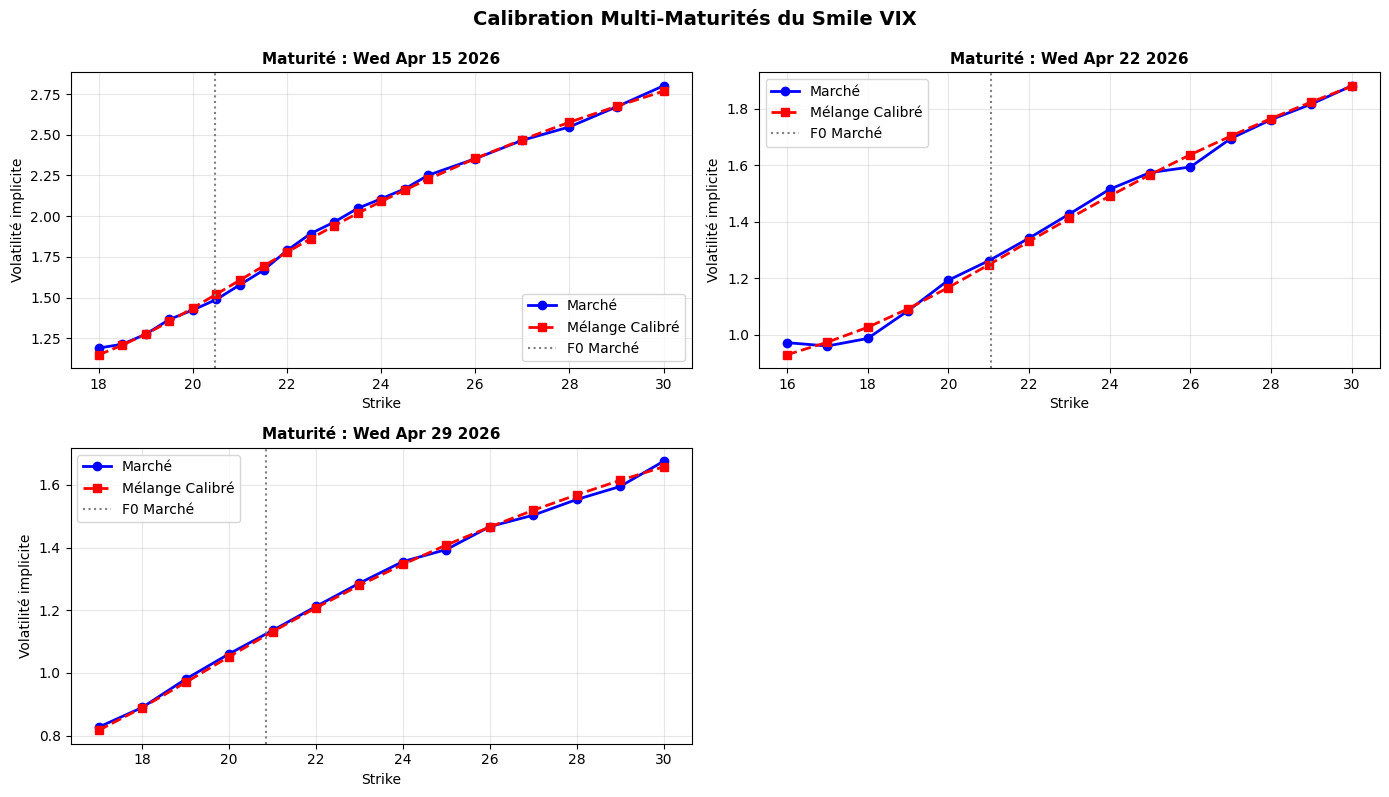

In [ ]:
# Affichage du tableau synthétique de la calibration
print("TABLEAU SYNTHÉTIQUE DE LA CALIBRATION")
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Configuration de l'affichage en grille
n_plots = len(expiries_valides)
ncols = 2
nrows = int(np.ceil(n_plots / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

# Traçage itératif des graphiques pour chaque maturité
for idx, exp in enumerate(expiries_valides):
    ax = axes[idx]
    plot_data = fits[exp]

    ax.plot(plot_data["strikes"], plot_data["iv_mkt"], "o-", color="blue", lw=2, label="Marché")
    ax.plot(plot_data["strikes"], plot_data["iv_model"], "s--", color="red", lw=2, label="Mélange Calibré")

    ax.axvline(data_par_maturite[exp]["F0_mkt"], color="gray", ls=":", label="F0 Marché")

    ax.set_title(f"Maturité : {exp}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Volatilité implicite")
    ax.grid(True, alpha=0.3)
    ax.legend()

# Masquage des zones d'axes inutilisées
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

plt.suptitle("Calibration Multi-Maturités du Smile VIX", fontsize=14, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()